# **医学人工智能实践：回归任务**

**课程目标**：学习如何使用回归分析解决医学中的预测问题

**医学场景**：根据患者特征预测糖尿病病情进展

## **1. 什么是回归？**

### **1.1 从医学案例开始**
想象你在医院的内分泌科工作，你需要根据患者的各项指标来预测他们的病情进展。

比如：
- 根据身高预测体重（简单线性回归）
- 根据年龄、BMI、血压预测糖尿病病情进展（多元线性回归）

**回归**就是：**用已知的特征来预测一个连续的数值结果**。

### **1.2 回归 vs 聚类**
还记得我们上一节课学的**聚类**吗？让我们对比一下：

- **聚类**：没有标签，自动把相似的患者分组（比如：把糖尿病患者分成几个亚型）
- **回归**：有标签（目标值），预测一个具体的数值（比如：预测病情进展数值）

**类比理解**：
- 聚类就像：把一群人按照相似性分成几个班级
- 回归就像：根据考试前的各项指标，预测某个人考试的具体分数

## **2. 线性回归的基本思想**

### **2.1 "找一条最合适的线"**
线性回归的核心思想很简单：**找到一条最合适的直线，让它尽可能地接近所有的数据点**。

### **2.2 为什么要用直线？**

**医学直觉**：很多医学指标之间存在线性关系
- 身高越高，体重通常越重
- 血压越高，心血管风险通常越大

**简单性**：直线是最简单的数学关系，便于理解和解释

**直观理解**：
```
病情进展
    ↑
30 |                    ●
25 |                ●
20 |            ●
15 |        ●
10 |    ●
5  | ●
   +------------------→ BMI
       拟合直线 →
```

直线的方程：`y = a + b×x`
- `y`：我们要预测的目标（如病情进展）
- `x`：已知的特征（如BMI）
- `a`：截距（当x=0时，y的值）
- `b`：斜率（x每增加1，y增加多少）

### **2.3 什么是"最合适"的直线？——损失函数**

**关键概念：均方误差（Mean Squared Error, MSE）**

**医学类比**：
- 想象你在为病人测量体温，真实值是37.2°C
- 你的预测值是37.5°C，差值是0.3°C
- 如果预测10次，我们想知道总体的预测准确程度

**MSE的工作原理**：
1. 计算每个预测值与真实值的差距（误差）
2. 对这些误差求平方（消除负号，放大大的误差）
3. 求所有误差平方的平均值

**目标**：找到让MSE最小的那条直线

```python
# MSE的计算公式（数学表示，不用背）
# MSE = (1/n) × Σ(预测值 - 真实值)²
```

## **3. 本节课的任务：预测糖尿病病情进展**

### **3.1 数据集介绍**

我们将使用经典**糖尿病数据集**，包含442名糖尿病患者的信息：

**数据集来源**：
- 来自美国国家糖尿病、消化和肾脏疾病研究所（NIDDK）
- 作为机器学习中的经典回归任务数据集，广泛应用于算法测试和教学

**数据集基本信息**：
- **样本数量**：442名糖尿病患者
- **特征数量**：10个自变量（基线测量指标）
- **目标变量**：1个因变量（疾病进展指标）
- **数据类型**：所有特征都已标准化（均值为0，标准差为1）
- **缺失值**：无，数据完整

**特征（输入）详细说明**：

| 序号 | 特征名称 | 英文名称 | 含义说明 |
|------|----------|----------|----------|
| 1 | 年龄 | Age | 患者年龄（岁） |
| 2 | 性别 | Sex | 患者性别（已编码） |
| 3 | 体质指数 | BMI | 体质指数 Body Mass Index（体重kg/身高²m²） |
| 4 | 平均血压 | BP | 平均血压 Blood Pressure（mmHg） |
| 5 | 总胆固醇 | S1 | 总血清胆固醇（TC） |
| 6 | 低密度脂蛋白 | S2 | 低密度脂蛋白（LDL） |
| 7 | 高密度脂蛋白 | S3 | 高密度脂蛋白（HDL） |
| 8 | 总胆固醇/HDL比值 | S4 | 总胆固醇/HDL比值（TC/HDL） |
| 9 | 血清甘油三酯 | S5 | 血清甘油三酯的对数（log of TG） |
| 10 | 血糖水平 | S6 | 血糖水平（血糖） |

**目标（输出）详细说明**：

- **变量名称**：疾病进展指标（Disease Progression）
- **测量方法**：在基线测量后一年，通过定量评价病情进展
- **数值含义**：病情进展的数值化表示，值越大表示病情越严重
- **取值范围**：约25到346（实际值）
- **临床意义**：反映糖尿病患者病情的恶化程度，是评估治疗效果和预后的重要指标

**数据集的重要特点**：

- **已标准化处理**：所有特征都经过标准化处理（均值为0，标准差为1），消除了不同特征之间的量纲差异，便于模型训练和比较
- **临床相关性**：选取的特征都是糖尿病相关的生理指标，具有明确的医学意义和临床价值
- **多维度信息**：包含人口统计学信息（年龄、性别）、身体指标（BMI、血压）和生化指标（血脂、血糖），全面反映患者状况
- **回归问题典型**：目标变量是连续值，非常适合作为回归任务的入门数据集

**为什么选这个数据集**：
- 真实医学数据，贴近临床实践
- 特征数量适中（10个），便于理解和解释
- 目标是连续值，适合回归分析
- 数据质量高，无缺失值
- 特征已标准化，减少数据预处理工作
- 机器学习领域的基准数据集，便于与文献对比

### **3.2 今天的实践步骤**

我们将按照以下步骤完成今天的实践：

1. **加载和探索数据集**：了解数据的样子
2. **数据划分**：把数据分成训练集和测试集
3. **创建和训练模型**：用训练数据找到"最合适的线"
4. **做出预测**：用模型预测测试数据
5. **评估模型**：用MSE和R²分数评估模型好坏
6. **可视化结果**：用图表直观看到预测效果

让我们开始吧！

## **4. 开始编码实践**

### **4.1 导入必要的库**

首先，我们需要导入Python中用于机器学习的主要工具：

In [1]:
# 导入必要的库
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 设置图表显示参数（让图表更清晰）
plt.rcParams['figure.dpi'] = 100  # 设置图像分辨率
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体（解决中文显示问题）
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 让图表直接在笔记本中显示
%matplotlib inline

### **4.2 加载和探索数据集**

In [2]:
# TODO: 请在此处填写代码，加载数据集
# 提示：使用 load_diabetes() 加载数据
diabetes = load_diabetes()

# 提取特征（X）和目标（y）
X = diabetes.data
y = diabetes.target

# 获取特征名称
feature_names = diabetes.feature_names

# 创建特征名称的中英文对照字典
feature_name_mapping = {
    'age': '年龄',
    'sex': '性别', 
    'bmi': '体质指数',
    'bp': '平均血压',
    's1': '总胆固醇',
    's2': '低密度脂蛋白',
    's3': '高密度脂蛋白',
    's4': '总胆固醇/HDL比值',
    's5': '血清甘油三酯',
    's6': '血糖水平'
}

# 查看数据的基本信息
print("数据集大小:")
print(f"患者数量（样本数）: {X.shape[0]}")
print(f"特征数量（变量数）: {X.shape[1]}")
print(f"\n特征名称:")
for i, name in enumerate(feature_names):
    print(f"特征{i+1}: {name} ({feature_name_mapping[name]})")
print(f"\n前5个患者的特征:")
print(X[:5])
print(f"\n前5个患者的病情进展指标:")
print(y[:5])
print(f"\n病情进展指标的范围: {y.min():.1f} 到 {y.max():.1f}")
print(f"病情进展指标的平均值: {y.mean():.1f}")

数据集大小:
患者数量（样本数）: 442
特征数量（变量数）: 10

特征名称:
特征1: age (年龄)
特征2: sex (性别)
特征3: bmi (体质指数)
特征4: bp (平均血压)
特征5: s1 (总胆固醇)
特征6: s2 (低密度脂蛋白)
特征7: s3 (高密度脂蛋白)
特征8: s4 (总胆固醇/HDL比值)
特征9: s5 (血清甘油三酯)
特征10: s6 (血糖水平)

前5个患者的特征:
[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059
  -0.03603757  0.03430886  0.02268774 -0.00936191]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614
   0.00814208 -0.00259226 -0.03198764 -0.04664087]]

前5个患者的病情进展指标:
[151.  75. 141. 206. 135.]

病情进展指标的范围: 25.0 到 346.0
病情进展指标的平均值: 152.1


**数据解读**：
- 我们有442名患者，每个患者有10个特征
- 目标值（病情进展）是一个数值
- 注意：这个数据集中的特征已经被标准化（均值为0，标准差为1），这是数据预处理的一种常用方法

### **4.3 数据集划分**

**为什么需要划分数据集？**

在机器学习中，我们不能用同一组数据来训练和测试模型，这就像：
- 期末考试需要靠与平时作业不同的题目进行公平的测试

**训练集 vs 测试集**：
- **训练集（80%）**：用来"教"模型（训练模型）
- **测试集（20%）**：用来"考"模型（验证模型是否真的学会了）

**重要原则**：模型在测试集上应该表现良好，这说明模型有泛化能力（能够处理新数据）

In [3]:
# TODO: 请在此处填写代码，划分数据集
# 提示：使用 train_test_split，测试集占20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 查看划分结果
print("数据集划分结果：")
print(f"训练集大小: {X_train.shape[0]} 个患者")
print(f"测试集大小: {X_test.shape[0]} 个患者")
print(f"训练集占比: {X_train.shape[0]/X.shape[0]*100:.1f}%")


数据集划分结果：
训练集大小: 353 个患者
测试集大小: 89 个患者
训练集占比: 79.9%


### **4.4 创建和训练模型**

现在我们开始构建**线性回归模型**：

**步骤1：创建模型对象**
- 就像准备一个"空的"回归模型

**步骤2：训练模型**
- 让模型从训练数据中"学习"特征和目标之间的关系
- 模型会找到让MSE最小的那条"最合适的线"（或高维的超平面）

这就像：
- 医生通过观察大量病人，学会"当BMI升高时，病情进展通常会加重"
- 线性回归模型会通过计算，找到精确的数学关系

In [4]:
# TODO: 请在此处填写代码，创建并训练模型
# 提示：1. 创建 LinearRegression 对象
#       2. 使用 .fit(X_train, y_train) 训练模型

# 创建线性回归模型
lr = LinearRegression()

# 使用训练数据训练模型
lr.fit(X_train, y_train)

# 获取特征名称
feature_names = diabetes.feature_names

# 创建特征名称的中英文对照字典
feature_name_mapping = {
    'age': '年龄',
    'sex': '性别', 
    'bmi': '体质指数',
    'bp': '平均血压',
    's1': '总胆固醇',
    's2': '低密度脂蛋白',
    's3': '高密度脂蛋白',
    's4': '总胆固醇/HDL比值',
    's5': '血清甘油三酯',
    's6': '血糖水平'
}

# 查看训练好的模型参数
print("模型训练完成！")
print(f"\n模型学到的关系：")
print(f"病情进展 = {lr.intercept_:.2f}")
for i, (coef, name) in enumerate(zip(lr.coef_, feature_names)):
    chinese_name = feature_name_mapping[name]
    print(f"{'+' if coef >= 0 else ''}{coef:.2f}×{chinese_name}({name})")

print(f"\n截距（a）: {lr.intercept_:.2f}")

# 找出影响最大的特征
max_coef_index = abs(lr.coef_).argmax()
max_coef = lr.coef_[max_coef_index]
max_feature_name = feature_names[max_coef_index]
max_chinese_name = feature_name_mapping[max_feature_name]
print(f"最大的系数（影响最大的特征）: {abs(max_coef):.2f}")
print(f"对应特征: {max_chinese_name}({max_feature_name})")

# 找出正负影响最大的特征
positive_coef_max = lr.coef_.max()
positive_coef_index = lr.coef_.argmax()
negative_coef_min = lr.coef_.min()
negative_coef_index = lr.coef_.argmin()

print(f"\n正向影响最大的特征: {feature_name_mapping[feature_names[positive_coef_index]]}({feature_names[positive_coef_index]}) = {positive_coef_max:.2f}")
print(f"负向影响最大的特征: {feature_name_mapping[feature_names[negative_coef_index]]}({feature_names[negative_coef_index]}) = {negative_coef_min:.2f}")

模型训练完成！

模型学到的关系：
病情进展 = 151.35
+37.90×年龄(age)
-241.96×性别(sex)
+542.43×体质指数(bmi)
+347.70×平均血压(bp)
-931.49×总胆固醇(s1)
+518.06×低密度脂蛋白(s2)
+163.42×高密度脂蛋白(s3)
+275.32×总胆固醇/HDL比值(s4)
+736.20×血清甘油三酯(s5)
+48.67×血糖水平(s6)

截距（a）: 151.35
最大的系数（影响最大的特征）: 931.49
对应特征: 总胆固醇(s1)

正向影响最大的特征: 血清甘油三酯(s5) = 736.20
负向影响最大的特征: 总胆固醇(s1) = -931.49


**模型参数解读**：
- **截距（intercept）**：当所有特征为0时，病情进展的基准值
- **系数（coef）**：每个特征对病情进展的影响程度
  - 系数的绝对值越大，该特征的影响越大
  - 系数为正：该特征增加，病情进展加重
  - 系数为负：该特征增加，病情进展减轻

**医学意义**：这告诉我们哪些生理指标对糖尿病病情进展影响最大，为临床干预提供指导。

### **4.5 使用模型进行预测**

模型训练完成后，我们就可以用它来**预测**新患者的病情进展：

In [5]:
# TODO: 请在此处填写代码，对训练集和测试集进行预测
# 提示：使用 .predict(X_train) 和 .predict(X_test)

# 对训练集进行预测（检查模型是否"记住"了训练数据）
y_pred_train = lr.predict(X_train)

# 对测试集进行预测（检查模型是否有泛化能力）
y_pred_test = lr.predict(X_test)

# 查看预测结果示例
print("预测结果示例（测试集前5名患者）：")
print("真实值 vs 预测值")
for i in range(5):
    print(f"患者{i+1}: {y_test[i]:.1f} vs {y_pred_test[i]:.1f} (误差: {abs(y_test[i]-y_pred_test[i]):.1f})")

# 计算平均预测值
print(f"\n平均真实值: {y_test.mean():.1f}")
print(f"平均预测值: {y_pred_test.mean():.1f}")


预测结果示例（测试集前5名患者）：
真实值 vs 预测值
患者1: 219.0 vs 139.5 (误差: 79.5)
患者2: 70.0 vs 179.5 (误差: 109.5)
患者3: 202.0 vs 134.0 (误差: 68.0)
患者4: 230.0 vs 291.4 (误差: 61.4)
患者5: 111.0 vs 123.8 (误差: 12.8)

平均真实值: 145.8
平均预测值: 141.9


**预测结果观察**：
- 预测值和真实值接近，说明模型预测得不错
- 每个预测都有一定误差，这是正常的
- 平均预测值接近平均真实值，说明模型没有系统性偏差

## **5. 评估模型性能**

我们用两个指标来评估模型的好坏：

### **5.1 均方误差（MSE）**
**含义**：预测误差的平均平方值

**特点**：
- 数值越小越好
- 对大误差敏感（因为平方了）
- 单位是目标值的平方

**医学类比**：
- 如果MSE=1000，意味着平均每个预测误差的平方是1000
- 相当于平均误差约 √1000 ≈ 32（在病情进展指标的尺度上）

In [6]:
# TODO: 请在此处填写代码，计算训练集和测试集的均方误差
# 提示：使用 mean_squared_error(y_true, y_pred)

# 计算训练集均方误差
mse_train = mean_squared_error(y_train, y_pred_train)

# 计算测试集均方误差
mse_test = mean_squared_error(y_test, y_pred_test)

print("模型性能评估（均方误差）：")
print(f"训练集MSE: {mse_train:.2f}")
print(f"测试集MSE: {mse_test:.2f}")
print(f"\n测试集相对训练集MSE增加: {(mse_test/mse_train-1)*100:.1f}%")


模型性能评估（均方误差）：
训练集MSE: 2868.55
测试集MSE: 2900.19

测试集相对训练集MSE增加: 1.1%


**MSE解读**：
- 训练集MSE应该较小（模型"记住"了训练数据）
- 测试集MSE不应比训练集大太多（说明模型有泛化能力）
- 如果测试集MSE远大于训练集MSE，可能是**过拟合**（模型太复杂，死记硬背了训练数据）

### **5.2 R²分数（决定系数）**

**什么是R²？**

R²（R-squared）是衡量回归模型好坏的重要指标。

**核心概念**：R²告诉我们模型解释了数据中多少比例的"变化"（Variation）。

**"变化"是什么意思？**

举个简单的例子：
- 如果所有学生的成绩都是80分，那么这个数据"没有变化"
- 如果学生成绩从40分到100分不等，那么这个数据"变化很大"

**R²的含义**：
- R² = 0.80 表示：模型解释了数据变化的80%
- R² = 0.50 表示：模型解释了数据变化的50%
- R² = 0.00 表示：模型没有解释任何变化（预测和用均值一样）

**计算公式**：

```
R² = 1 - (预测误差平方和 / 数据总变化)
```

简单理解：
- 分母：数据的总变化有多大
- 分子：模型预测后还剩下多少变化没解释
- 结果：模型成功解释了多少比例的变化

**R²的取值范围**：

| R²值 | 含义 |
|------|------|
| R² > 0.7 | 模型很好，解释了大部分变化 |
| R² 在 0.4-0.7 | 模型中等，有一定预测能力 |
| R² < 0.4 | 模型较差 |

**医学例子**：
- 糖尿病患者的病情进展从25到346，变化很大
- 如果R² = 0.50，说明用年龄、BMI、血压等特征，能解释病情进展变化的50%
- 另外50%的变化，可能是遗传、饮食、运动等未知因素造成的

**与MSE的区别**：
- **MSE**：看预测误差有多大（绝对值）
- **R²**：看模型解释了多少变化（比例）

In [7]:
# TODO: 请在此处填写代码，计算训练集和测试集的R²分数
# 提示：使用 r2_score(y_true, y_pred)

# 计算训练集R²分数
r2_train = r2_score(y_train, y_pred_train)

# 计算测试集R²分数
r2_test = r2_score(y_test, y_pred_test)

print("模型性能评估（R²分数）：")
print(f"训练集R²: {r2_train:.4f} = {r2_train*100:.2f}%")
print(f"测试集R²: {r2_test:.4f} = {r2_test*100:.2f}%")

# 模型质量评估
print("\n模型质量评价：")
if r2_test > 0.6:
    print("✓ 模型表现良好，能够解释大部分变异")
elif r2_test > 0.4:
    print("○ 模型表现中等，有一定的预测能力")
else:
    print("✗ 模型表现较差，需要改进")


模型性能评估（R²分数）：
训练集R²: 0.5279 = 52.79%
测试集R²: 0.4526 = 45.26%

模型质量评价：
○ 模型表现中等，有一定的预测能力


**R²解读**：
- R² > 0.7：模型表现良好
- R²在0.4-0.7：模型表现中等
- R² < 0.4：模型表现较差

**注意**：医学数据通常比较复杂，R²不一定很高，重要的是模型是否有实用价值。

## **6. 可视化结果**

用图表直观地展示模型的预测效果：

**散点图说明**：
- x轴：真实值
- y轴：预测值  
- 红色虚线：完美预测线（预测值=真实值）
- 数据点越靠近红色虚线，预测越准确

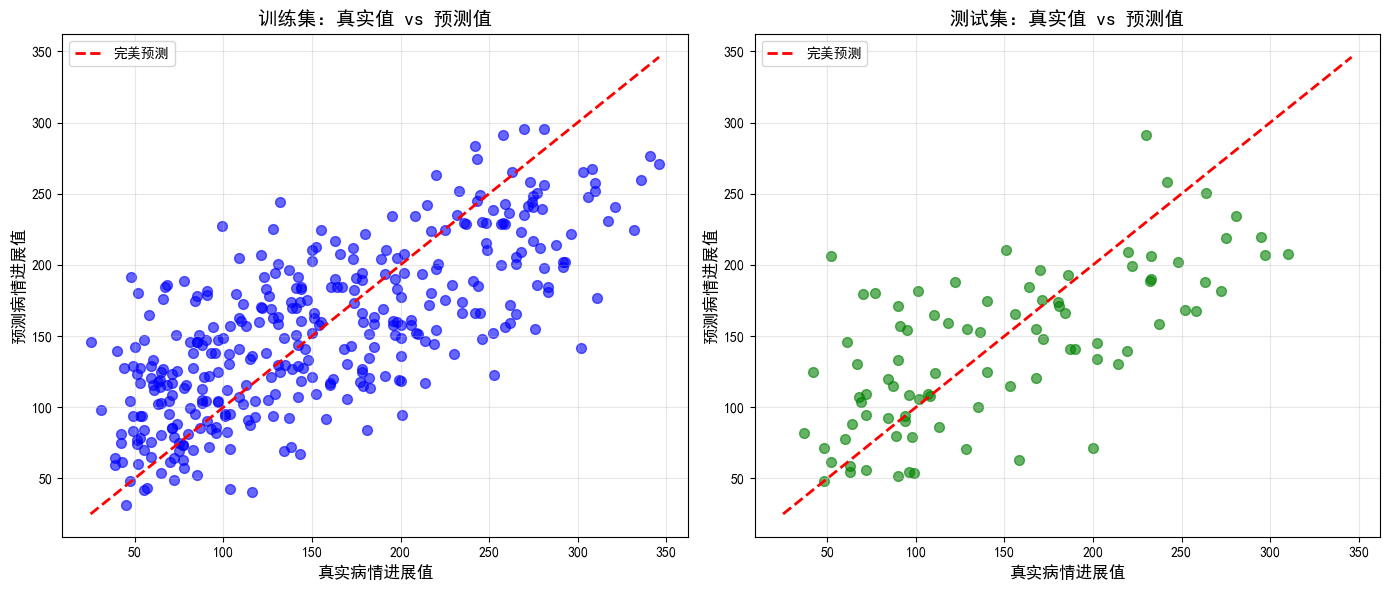

In [8]:
# 可视化实际值与预测值的关系
plt.figure(figsize=(14, 6))

# 训练集可视化
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, color='blue', alpha=0.6, s=50)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='完美预测')
plt.xlabel('真实病情进展值', fontsize=12)
plt.ylabel('预测病情进展值', fontsize=12)
plt.title('训练集：真实值 vs 预测值', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 测试集可视化
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, color='green', alpha=0.6, s=50)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='完美预测')
plt.xlabel('真实病情进展值', fontsize=12)
plt.ylabel('预测病情进展值', fontsize=12)
plt.title('测试集：真实值 vs 预测值', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**图表解读**：
- 点越靠近红色虚线，预测越准确
- 点散布在虚线周围，说明模型有随机误差
- 训练集和测试集的散布模式应该相似（说明模型稳定）
- 如果测试集点明显比训练集分散，说明可能有过拟合

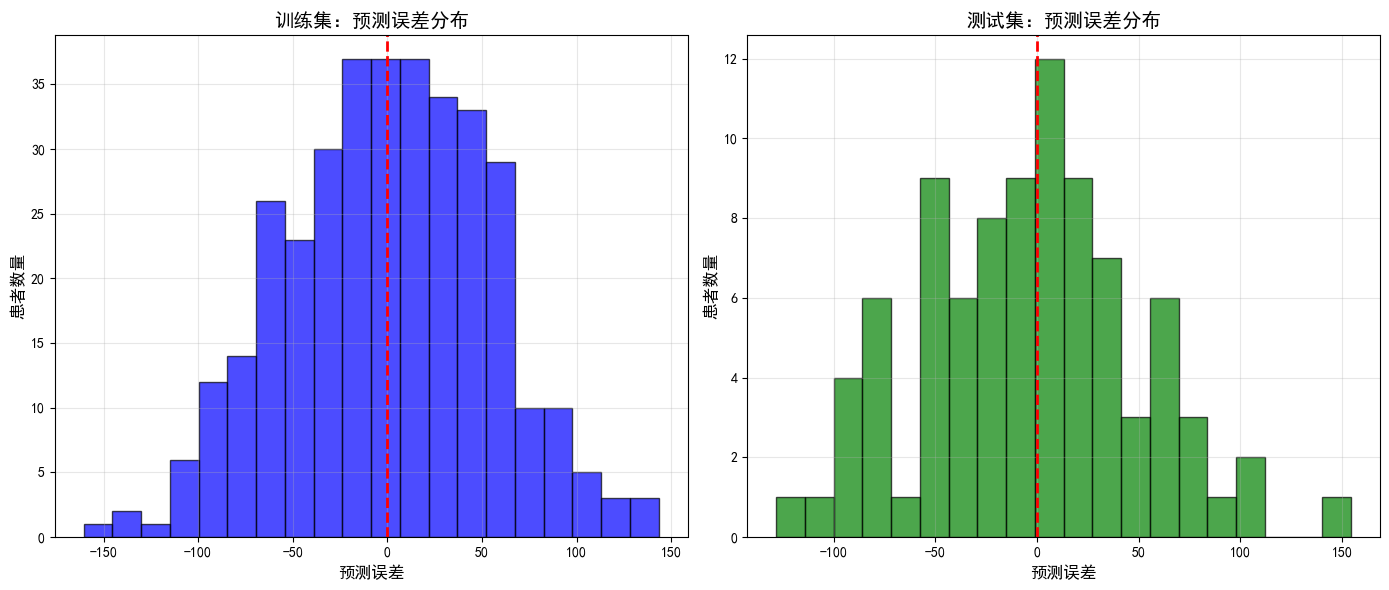

预测误差统计：
训练集误差范围: [-160.6, 143.4]
训练集平均误差: 0.00
训练集误差标准差: 53.56

测试集误差范围: [-128.3, 154.5]
测试集平均误差: -3.91
测试集误差标准差: 53.71


In [9]:
# 可视化预测误差分布
plt.figure(figsize=(14, 6))

# 训练集误差分布
plt.subplot(1, 2, 1)
errors_train = y_pred_train - y_train
plt.hist(errors_train, bins=20, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('预测误差', fontsize=12)
plt.ylabel('患者数量', fontsize=12)
plt.title('训练集：预测误差分布', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# 测试集误差分布
plt.subplot(1, 2, 2)
errors_test = y_pred_test - y_test
plt.hist(errors_test, bins=20, color='green', alpha=0.7, edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('预测误差', fontsize=12)
plt.ylabel('患者数量', fontsize=12)
plt.title('测试集：预测误差分布', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印误差统计信息
print("预测误差统计：")
print(f"训练集误差范围: [{errors_train.min():.1f}, {errors_train.max():.1f}]")
print(f"训练集平均误差: {errors_train.mean():.2f}")
print(f"训练集误差标准差: {errors_train.std():.2f}")
print(f"\n测试集误差范围: [{errors_test.min():.1f}, {errors_test.max():.1f}]")
print(f"测试集平均误差: {errors_test.mean():.2f}")
print(f"测试集误差标准差: {errors_test.std():.2f}")

**误差分布解读**：
- 理想情况下，误差应该以0为中心，呈正态分布
- 平均误差接近0：模型没有系统性偏差
- 误差标准差：衡量预测的不确定性
- 训练集和测试集误差分布相似：模型稳定

## **7. 医学应用与思考**

### **7.1 模型的临床意义**

**这个回归模型在医学上的价值**：

1. **风险分层**：根据患者特征预测病情进展，帮助医生识别高危患者
2. **个性化治疗**：为不同风险水平的患者制定不同的治疗方案
3. **效果评估**：追踪治疗过程中的病情变化，评估治疗效果

### **7.2 模型的局限性**

**需要注意的限制**：

1. **相关非因果**：模型发现的是相关性，不一定是因果关系
2. **个体差异**：模型给出的是平均预测，个体实际情况可能不同
3. **时间因素**：数据来自某个时间段，不一定适用于所有时期
4. **种族/人群差异**：数据集可能存在人群代表性问题


## **8. 实践总结**

### **8.1 今天我们学到了什么**

**核心概念**：
- **回归**：用特征预测连续数值
- **线性回归**：找到最合适的直线（或超平面）来拟合数据
- **损失函数（MSE）**：衡量预测误差的方法
- **R²分数**：评估模型解释变异的能力

**实践步骤**：
1. 加载数据 → 了解数据
2. 划分数据 → 训练集/测试集
3. 创建模型 → LinearRegression
4. 训练模型 → .fit()
5. 做出预测 → .predict()
6. 评估模型 → MSE和R²
7. 可视化结果 → 散点图和误差分布

### **8.2 与上节课（聚类）的对比**

| 维度 | 聚类 | 回归 |
|------|------|------|
| 是否需要标签 | 无监督学习 | 有监督学习 |
| 输出类型 | 分组标签 | 连续数值 |
| 医学应用 | 患者分型 | 疾病预测 |
| 评估指标 | 轮廓系数 | MSE、R² |

## **9. 课后思考**

**思考题 (可选)**：

1. 如果你想预测患者的住院天数，应该用聚类还是回归？为什么？

2. 在本例中，哪个特征对糖尿病病情进展影响最大？这对临床有什么意义？

3. 如果测试集的R²远低于训练集的R²，可能是什么问题？如何解决？

4. 除了线性回归，你知道其他类型的回归方法吗？（提示：逻辑回归、多项式回归等）

**扩展阅读**：
- 学习更多回归方法（岭回归、Lasso回归）
- 了解机器学习在医学中的其他应用（疾病诊断、药物发现等）
- 探索如何提高模型性能（特征工程、模型调参等）

---

**恭喜你完成了医学人工智能回归任务的实践！** 🎉

通过今天的练习，你已经掌握了：
- 理解回归的基本思想和应用场景
- 使用线性回归解决医学预测问题
- 评估和解释模型的性能
- 理解机器学习在医学中的价值和局限性
